> # How Word2Vec Works: 

A Beginner-Friendly Tutorial

This notebook is a detailed companion to `26-Word2vec_Practical_Implementation.ipynb`.
That notebook demonstrates the practical side: load vectors, inspect nearest words, compare similarity, and solve analogies like `king - man + woman`.

Here we slow down and answer the beginner questions:

- What problem does Word2Vec solve?
- Why can a word be represented as a vector?
- What does "context" mean?
- What are CBOW and Skip-gram?
- How do we train a small Word2Vec model ourselves?
- How do similarity, nearest neighbors, and analogies work?
- What are the common pitfalls when interpreting word vectors?

By the end, you should be able to explain Word2Vec in plain language and use `gensim` to train and inspect a small model.

## 1. Learning Goals and Prerequisites


**You will learn:**

1. How words become numeric vectors.
2. How context windows create training examples.
3. The difference between CBOW and Skip-gram.
4. How to train Word2Vec with `gensim`.
5. How to use `most_similar`, `similarity`, and vector arithmetic.
6. Why small datasets can produce unstable or surprising results.

## 2. Setup

The only external package we truly need for Word2Vec is `gensim`.
`numpy` and `pandas` help us inspect results, and `matplotlib` helps us visualize vectors.

If a package is missing, uncomment the install line in the next cell and run it once.

In [1]:
# If needed, uncomment this line and run the cell once:
# %pip install gensim pandas matplotlib numpy

import re
from collections import Counter

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    from gensim.models import Word2Vec
    import gensim.downloader as api
    print("gensim is ready")
except ImportError as exc:
    raise ImportError(
        "Please install gensim first. In a notebook cell, run: %pip install gensim"
    ) from exc

gensim is ready


## 3. The Main Idea: Meaning Comes From Context

Word2Vec is built on the **distributional hypothesis**:

> Words that appear in similar contexts tend to have similar meanings.

For example, these sentences have similar structure:

- `the king wears a crown`
- `the queen wears a crown`
- `the prince wears a crown`

If `king`, `queen`, and `prince` repeatedly appear near words like `crown`, `royal`, `palace`, and `throne`, Word2Vec learns that their vectors should be close together.

A Word2Vec model does not learn meaning from a dictionary definition. It learns meaning from repeated neighboring-word patterns.

In [2]:
sentences_raw = [
    "the king rules the kingdom from the palace",
    "the queen rules the kingdom from the palace",
    "the prince lives in the royal palace",
    "the princess lives in the royal palace",
    "the king and queen wear a crown",
    "the prince and princess wear a crown",
    "the man drives a car on the road",
    "the woman drives a car on the road",
    "the boy rides a bicycle on the road",
    "the girl rides a bicycle on the road",
    "football and cricket are popular sports",
    "hockey and cricket are team sports",
    "football players train for the match",
    "cricket players train for the match",
    "tea and coffee are hot drinks",
    "pizza and pasta are tasty food",
]

def simple_tokenize(text):
    """Lowercase text and keep only alphabetic tokens."""
    return re.findall(r"[a-z]+", text.lower())

sentences = [simple_tokenize(sentence) for sentence in sentences_raw]
sentences[:3]

[['the', 'king', 'rules', 'the', 'kingdom', 'from', 'the', 'palace'],
 ['the', 'queen', 'rules', 'the', 'kingdom', 'from', 'the', 'palace'],
 ['the', 'prince', 'lives', 'in', 'the', 'royal', 'palace']]

## 4. What Is a Context Window?

Word2Vec does not read the whole sentence at once in the way humans do.
It looks at a word and a small number of neighboring words around it.

If the sentence is:

`the king rules the kingdom`

and the center word is `king` with `window = 2`, the context words are:

- `the`
- `rules`
- possibly words two positions away, depending on sentence length

This turns raw text into many small training examples.

In [3]:
def context_windows(tokens, window_size=2):
    rows = []
    for i, center_word in enumerate(tokens):
        start = max(0, i - window_size)
        end = min(len(tokens), i + window_size + 1)
        context = [tokens[j] for j in range(start, end) if j != i]
        rows.append({
            "position": i,
            "center_word": center_word,
            "context_words": context,
        })
    return pd.DataFrame(rows)

example_sentence = simple_tokenize("the king rules the kingdom from the palace")
context_windows(example_sentence, window_size=2)

,position,center_word,context_words
0,0,the,"[king, rules]"
1,1,king,"[the, rules, the]"
2,2,rules,"[the, king, the, kingdom]"
3,3,the,"[king, rules, kingdom, from]"
4,4,kingdom,"[rules, the, from, the]"
5,5,from,"[the, kingdom, the, palace]"
6,6,the,"[kingdom, from, palace]"
7,7,palace,"[from, the]"


## 5. CBOW vs Skip-gram

Word2Vec has two common training styles.

**CBOW: Continuous Bag of Words**

- Input: nearby context words
- Target: the center word
- Example: `[the, rules] -> king`
- Usually faster and useful when you have lots of frequent words

**Skip-gram**

- Input: the center word
- Target: each nearby context word
- Example: `king -> the`, `king -> rules`
- Often better for smaller datasets or rare words

Both approaches force the model to place words with similar contexts close together in vector space.

In [4]:
def make_skipgram_pairs(tokens, window_size=2):
    pairs = []
    for i, center_word in enumerate(tokens):
        start = max(0, i - window_size)
        end = min(len(tokens), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                pairs.append((center_word, tokens[j]))
    return pairs

pairs = make_skipgram_pairs(example_sentence, window_size=2)
pd.DataFrame(pairs, columns=["input_center_word", "target_context_word"])

,input_center_word,target_context_word
0,the,king
1,the,rules
2,king,the
3,king,rules
4,king,the
5,rules,the
6,rules,king
7,rules,the
8,rules,kingdom
9,the,king


## 6. What Is the Model Actually Learning?

At the beginning of training, every word gets a random vector.
During training, the model repeatedly sees examples such as:

- `king -> palace`
- `queen -> palace`
- `cricket -> sports`
- `football -> sports`

The model updates vectors so that useful predictions become more likely.
After many updates:

- words with similar contexts become close together,
- unrelated words tend to be farther apart,
- some directions in vector space capture relationships such as gender, tense, location, or category.

A key detail: Word2Vec is usually trained with a shortcut called **negative sampling**.
Instead of predicting one context word from the full vocabulary every time, it trains on a few "positive" examples and a few randomly sampled "negative" examples. This makes training much faster.

## 7. Train a Tiny Skip-gram Word2Vec Model

Now we will train our own small model.

Important note: this toy dataset is intentionally tiny so that the notebook runs quickly. Real Word2Vec models are trained on millions or billions of words. On tiny text, results are useful for learning the mechanics, but they may be noisy.

In [5]:
# Repeat the small corpus a few times so the model sees patterns more than once.
# This is still tiny compared with real-world Word2Vec training.
training_sentences = sentences * 80

model = Word2Vec(
    sentences=training_sentences,
    vector_size=50,   # each word becomes a 50-dimensional vector
    window=2,         # look 2 words left and 2 words right
    min_count=1,      # keep all words, even rare ones, for this demo
    workers=1,        # deterministic/reproducible for teaching
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    negative=5,       # number of negative samples
    epochs=200,
    seed=42,
)

print("Vocabulary size:", len(model.wv))
print("Vector size:", model.wv.vector_size)
print("First 15 words:", model.wv.index_to_key[:15])

Vocabulary size: 45
Vector size: 50
First 15 words: ['the', 'a', 'and', 'are', 'road', 'on', 'palace', 'cricket', 'match', 'for', 'train', 'players', 'sports', 'football', 'bicycle']


## 8. Inspect a Word Vector

A word vector is just a list of numbers.
The numbers themselves are not directly interpretable one by one. The useful information is in the **relative position** of vectors.

For example, we usually do not ask, "What does dimension 17 mean?"
Instead we ask:

- Which words are closest to `king`?
- Is `king` closer to `queen` than to `pizza`?
- Does `king - man + woman` land near `queen`?

In [6]:
word = "king"
vector = model.wv[word]

print(f"Vector for '{word}' has shape:", vector.shape)
print("First 10 numbers:")
np.round(vector[:10], 4)

Vector for 'king' has shape: (50,)
First 10 numbers:


array([-0.2992, -0.4601, -0.586 ,  0.6042, -0.4378, -0.3007,  0.24  ,
       -0.1883, -0.7642, -0.2977], dtype=float32)

## 9. Nearest Neighbors with `most_similar`

`most_similar(word)` asks:

> Which words have vectors closest to this word's vector?

Gensim uses **cosine similarity** by default. Cosine similarity compares direction, not raw length.

- `1.0` means same direction
- `0.0` means unrelated direction
- `-1.0` means opposite direction

In [7]:
for query in ["king", "queen", "cricket", "pizza", "road"]:
    print(f"\nMost similar to '{query}':")
    for neighbor, score in model.wv.most_similar(query, topn=5):
        print(f"  {neighbor:10s} {score:.3f}")


Most similar to 'king':
  queen      0.706
  from       0.579
  kingdom    0.558
  rules      0.538
  princess   0.522

Most similar to 'queen':
  king       0.706
  from       0.586
  kingdom    0.564
  rules      0.540
  prince     0.538

Most similar to 'cricket':
  football   0.618
  sports     0.612
  popular    0.489
  match      0.483
  for        0.482

Most similar to 'pizza':
  food       0.759
  tasty      0.735
  pasta      0.682
  hockey     0.501
  are        0.452

Most similar to 'road':
  on         0.662
  drives     0.550
  man        0.547
  girl       0.543
  boy        0.542


## 10. Compare Similarity Scores

Let us compare pairs that should be related and pairs that should be less related.

Because the dataset is tiny, do not expect perfect semantic understanding. The goal is to observe the mechanics.

In [8]:
pairs_to_compare = [
    ("king", "queen"),
    ("prince", "princess"),
    ("cricket", "football"),
    ("cricket", "sports"),
    ("king", "pizza"),
    ("road", "palace"),
]

rows = []
for a, b in pairs_to_compare:
    rows.append({"word_1": a, "word_2": b, "cosine_similarity": model.wv.similarity(a, b)})

pd.DataFrame(rows).sort_values("cosine_similarity", ascending=False)

,word_1,word_2,cosine_similarity
1,prince,princess,0.713399
0,king,queen,0.706389
2,cricket,football,0.617885
3,cricket,sports,0.611968
4,king,pizza,0.365830
5,road,palace,0.254634


## 11. Vector Arithmetic and Analogies

The original notebook used this idea:

```python
wv['king'] - wv['man'] + wv['woman']
```

The intuition is:

- Start at `king`
- Remove the direction associated with `man`
- Add the direction associated with `woman`
- The result may land near `queen`

This works best in large, high-quality pretrained models. It may only partially work in our tiny model, but the code is the same.

In [9]:
def analogy(a, b, c, topn=5):
    """Return words similar to: a - b + c."""
    return model.wv.most_similar(positive=[a, c], negative=[b], topn=topn)

examples = [
    ("king", "man", "woman"),
    ("prince", "boy", "girl"),
    ("football", "players", "sports"),
]

for a, b, c in examples:
    print(f"\n{a} - {b} + {c}:")
    for word, score in analogy(a, b, c):
        print(f"  {word:10s} {score:.3f}")


king - man + woman:
  queen      0.706
  from       0.588
  kingdom    0.568
  rules      0.543
  princess   0.527

prince - boy + girl:
  princess   0.720
  royal      0.600
  in         0.568
  queen      0.542
  lives      0.529

football - players + sports:
  team       0.635
  hockey     0.622
  cricket    0.604
  coffee     0.418
  are        0.404


## 12. Visualize Word Vectors in 2D

Our vectors have 50 dimensions, which humans cannot directly see.
To plot them, we reduce 50 dimensions down to 2 dimensions using a simple linear method based on Singular Value Decomposition (SVD).

This plot is only a rough map. Distances can be distorted when high-dimensional vectors are squeezed into 2D.

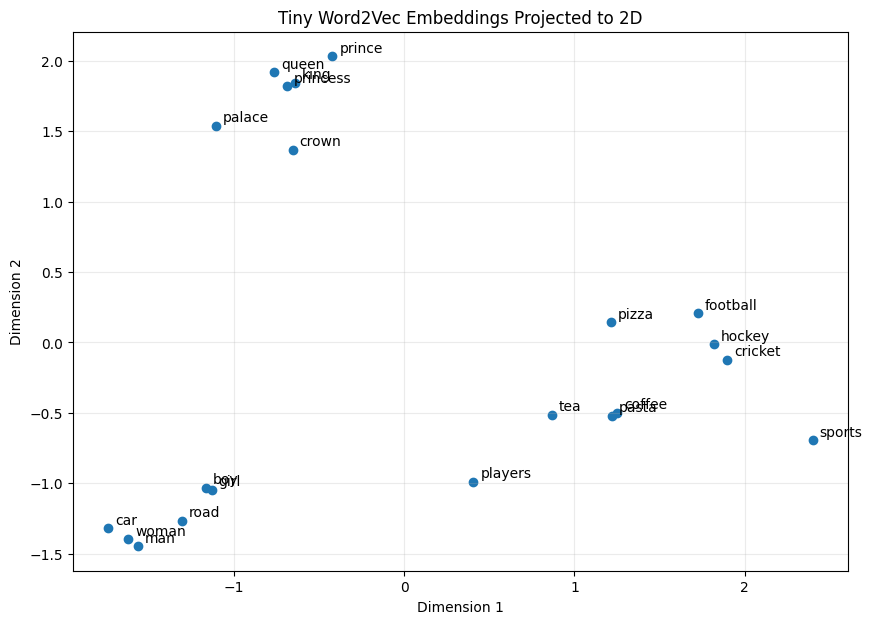

In [10]:
words_to_plot = [
    "king", "queen", "prince", "princess", "palace", "crown",
    "man", "woman", "boy", "girl", "road", "car",
    "cricket", "football", "hockey", "sports", "players",
    "pizza", "pasta", "tea", "coffee",
]

X = np.array([model.wv[word] for word in words_to_plot])
X_centered = X - X.mean(axis=0)

# Project to 2D using SVD. This avoids adding a scikit-learn dependency.
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords = X_centered @ Vt[:2].T

plot_df = pd.DataFrame({
    "word": words_to_plot,
    "x": coords[:, 0],
    "y": coords[:, 1],
})

if plt is None:
    print("matplotlib is not installed. Here are the 2D coordinates instead:")
    display(plot_df)
else:
    plt.figure(figsize=(10, 7))
    plt.scatter(plot_df["x"], plot_df["y"])
    for _, row in plot_df.iterrows():
        plt.annotate(row["word"], (row["x"], row["y"]), xytext=(5, 3), textcoords="offset points")
    plt.title("Tiny Word2Vec Embeddings Projected to 2D")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(alpha=0.25)
    plt.show()

## 13. CBOW Version for Comparison

Now train a CBOW model on the same data.

Remember:

- `sg=1` means Skip-gram
- `sg=0` means CBOW

The code is almost identical. Only the training objective changes.

In [11]:
cbow_model = Word2Vec(
    sentences=training_sentences,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=0,      # CBOW
    negative=5,
    epochs=200,
    seed=42,
)

comparison_rows = []
for a, b in pairs_to_compare:
    comparison_rows.append({
        "word_1": a,
        "word_2": b,
        "skipgram_similarity": model.wv.similarity(a, b),
        "cbow_similarity": cbow_model.wv.similarity(a, b),
    })

pd.DataFrame(comparison_rows).sort_values("skipgram_similarity", ascending=False)

,word_1,word_2,skipgram_similarity,cbow_similarity
1,prince,princess,0.713399,0.740154
0,king,queen,0.706389,0.756264
2,cricket,football,0.617885,0.677052
3,cricket,sports,0.611968,0.476051
4,king,pizza,0.365830,0.293598
5,road,palace,0.254634,-0.143713


## 14. Using Pretrained Vectors Like the Practical Notebook

The practical notebook uses `gensim.downloader` to load pretrained vectors and then explores words like `cricket`, `happy`, `hockey`, `sports`, and the `king - man + woman` analogy.

Pretrained vectors are much better than our toy model because they were trained on large corpora.

The full Google News model is very large. For a lighter tutorial, the next cell uses `glove-wiki-gigaword-50`, which is usually much smaller and easier to download.

If you do not have internet access, skip this section. Everything above still explains the mechanics.

In [12]:
# This cell needs internet the first time because gensim downloads the pretrained vectors.
# It can take a few minutes depending on your connection.

try:
    pretrained_wv = api.load("glove-wiki-gigaword-50")
    print("Loaded pretrained vectors:", len(pretrained_wv), "words")
    print("Vector size:", pretrained_wv.vector_size)
except Exception as exc:
    pretrained_wv = None
    print("Could not load pretrained vectors.")
    print("Reason:", exc)
    print("You can still use the trained-from-scratch model above.")

[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded pretrained vectors: 400000 words
Vector size: 50


In [13]:
if pretrained_wv is not None:
    for query in ["cricket", "happy", "king"]:
        print(f"\nMost similar to '{query}' using pretrained vectors:")
        for neighbor, score in pretrained_wv.most_similar(query, topn=5):
            print(f"  {neighbor:12s} {score:.3f}")
else:
    print("Pretrained vectors were not loaded, so this example is skipped.")


Most similar to 'cricket' using pretrained vectors:
  indies       0.809
  twenty20     0.809
  rugby        0.804
  cricketers   0.798
  england      0.780

Most similar to 'happy' using pretrained vectors:
  'm           0.914
  everyone     0.898
  everybody    0.897
  really       0.884
  me           0.878

Most similar to 'king' using pretrained vectors:
  prince       0.824
  queen        0.784
  ii           0.775
  emperor      0.774
  son          0.767


In [14]:
if pretrained_wv is not None:
    print("Similarity between hockey and sports:", pretrained_wv.similarity("hockey", "sports"))
    print("\nking - man + woman:")
    for word, score in pretrained_wv.most_similar(positive=["king", "woman"], negative=["man"], topn=5):
        print(f"  {word:12s} {score:.3f}")
else:
    print("Pretrained vectors were not loaded, so this example is skipped.")

Similarity between hockey and sports: 0.6971474

king - man + woman:
  queen        0.852
  throne       0.766
  prince       0.759
  daughter     0.747
  elizabeth    0.746


## 15. Exercise: Add Your Own Mini Domain

Try adding 5-10 sentences about one domain, such as healthcare, finance, movies, cricket, cooking, or programming.

Then retrain the model and answer:

1. Which words become nearest neighbors?
2. Which similarity scores make sense?
3. Which results are surprising?
4. Does increasing `window` change the neighbors?
5. Does increasing `epochs` make the results more stable?

The next cell gives you a scaffold.

In [15]:
my_sentences_raw = [
    # Add your own sentences here. Example:
    "python code runs in a notebook",
    "python developers write code",
    "data scientists use python notebooks",
    "machine learning models learn from data",
    "developers test code before deployment",
]

my_sentences = [simple_tokenize(sentence) for sentence in my_sentences_raw]

my_model = Word2Vec(
    sentences=my_sentences * 100,
    vector_size=30,
    window=2,
    min_count=1,
    workers=1,
    sg=1,
    negative=5,
    epochs=150,
    seed=42,
)

query_word = "python"
print(f"Most similar to '{query_word}':")
for word, score in my_model.wv.most_similar(query_word, topn=5):
    print(f"  {word:12s} {score:.3f}")

Most similar to 'python':
  notebook     0.536
  scientists   0.515
  in           0.495
  use          0.458
  a            0.455


## 16. Common Pitfalls

**Pitfall 1: Expecting tiny datasets to produce perfect meaning**

Word2Vec needs many examples. A toy dataset teaches the mechanics, but pretrained models usually produce better semantic results.

**Pitfall 2: Thinking each vector dimension has a clean human label**

Individual dimensions are usually not interpretable. Relationships between vectors are what matter.

**Pitfall 3: Ignoring preprocessing**

Tokenization, casing, punctuation, rare-word handling, and phrase detection can strongly affect results.

**Pitfall 4: Treating analogies as guaranteed truth**

Analogies are a neat property of many embeddings, but they are not guaranteed. They depend on the training data, model quality, and wording.

**Pitfall 5: Forgetting that embeddings can learn bias**

Word2Vec learns from text. If the text contains social, cultural, or historical bias, the vectors can reflect those patterns.

## 17. Quick Reference

Useful `gensim` Word2Vec methods:

```python
model.wv['king']
```
Returns the vector for a word.

```python
model.wv.most_similar('king')
```
Finds nearby words.

```python
model.wv.similarity('hockey', 'sports')
```
Computes cosine similarity between two words.

```python
model.wv.most_similar(positive=['king', 'woman'], negative=['man'])
```
Performs vector arithmetic for an analogy-style query.

Important training parameters:

- `vector_size`: number of dimensions in each word vector
- `window`: how many neighboring words count as context
- `min_count`: ignore words that appear fewer than this many times
- `sg`: `1` for Skip-gram, `0` for CBOW
- `negative`: number of negative samples
- `epochs`: number of passes over the training data

## 18. Final Summary

Word2Vec learns word vectors by training on neighboring-word prediction tasks.

The big idea is simple:

1. Convert text into tokens.
2. Create context-window examples.
3. Train a shallow neural model to predict words from contexts or contexts from words.
4. Use the learned weights as word vectors.
5. Compare vectors with cosine similarity.
6. Explore semantic relationships with nearest neighbors and vector arithmetic.

The practical notebook showed how to use vectors. This tutorial showed why those operations work and how to train a small model yourself.